In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('HHDD/heart_statlog_cleveland_hungary_final.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [5]:
df.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

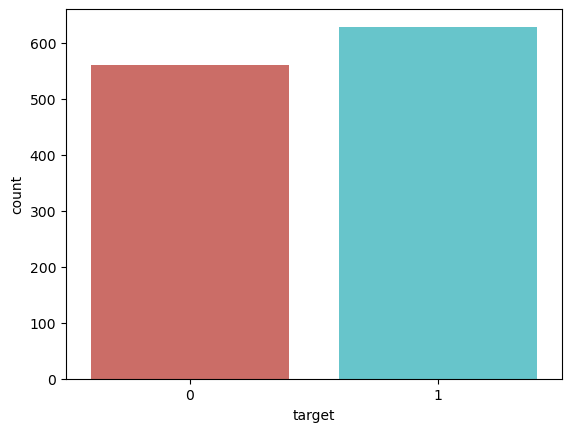

In [6]:
sns.countplot(x='target',data=df, palette='hls')
plt.show()
#plt.savefig('count_plot') mal: the nodule malignancy, 0: benign, 1: malignant

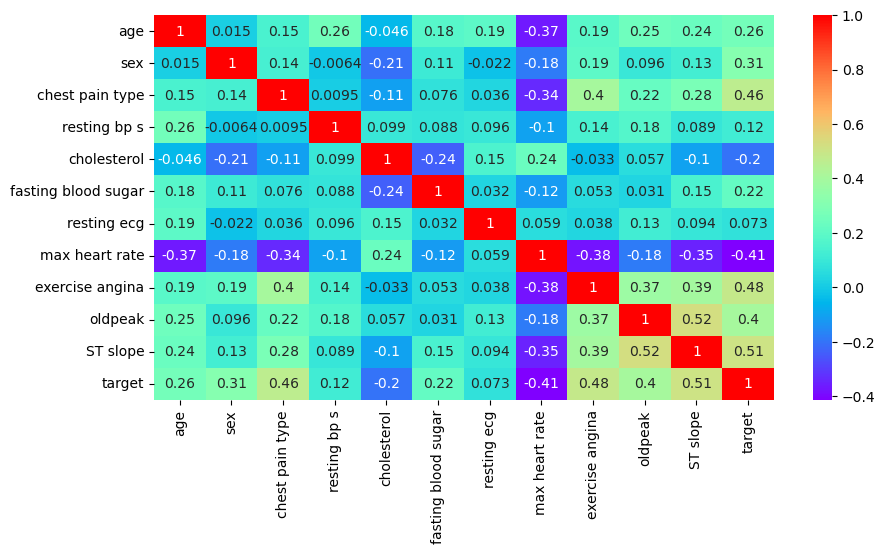

In [7]:
plt.figure(figsize = (10,5))
sns.heatmap(df.corr(), annot = True, cmap="rainbow")
plt.show()

In [8]:
X = df.drop(["target"],axis =1)
y = df["target"]

# Anova FS

In [9]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [11]:
selector = SelectKBest(f_classif, k=8) # k is the number of features to be selected
X_new = selector.fit_transform(X, y)

In [12]:
selected_features = df.columns[:-1][selector.get_support()]
print("\nSelected Features:")
print(selected_features)


Selected Features:
Index(['age', 'sex', 'chest pain type', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak', 'ST slope'],
      dtype='object')


In [14]:
df = df[['age', 'sex', 'chest pain type', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak', 'ST slope','target']]

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   fasting blood sugar  1190 non-null   int64  
 4   max heart rate       1190 non-null   int64  
 5   exercise angina      1190 non-null   int64  
 6   oldpeak              1190 non-null   float64
 7   ST slope             1190 non-null   int64  
 8   target               1190 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 83.8 KB


# PSO

In [16]:
X = df.drop(["target"],axis =1)
y = df["target"]

In [17]:
X = X.values

In [18]:
y = y.values

In [19]:
feat  = np.asarray(X)
label = np.asarray(y)

In [21]:
# split data into train & validation (70 -- 30)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(feat, label, test_size=0.3, stratify=label)
fold = {'xt':xtrain, 'yt':ytrain, 'xv':xtest, 'yv':ytest}

In [23]:
from FS.pso import jfs   # change this to switch algorithm 

In [24]:
# parameter
k    = 5     # k-value
N    = 5    # number of particles
T    = 5   # maximum number of iterations
opts = {'k':k, 'fold':fold, 'N':N, 'T':T}

# perform feature selection
fmdl = jfs(feat, label, opts)
sf   = fmdl['sf']

Iteration: 1
Best (PSO): 0.19482142857142856
Iteration: 2
Best (PSO): 0.19482142857142856
Iteration: 3
Best (PSO): 0.16709033613445376
Iteration: 4
Best (PSO): 0.16709033613445376
Iteration: 5
Best (PSO): 0.16709033613445376


In [25]:
df.columns

Index(['age', 'sex', 'chest pain type', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')

In [26]:
sf

array([1, 2, 3, 6, 7])

In [28]:
# model with selected features
num_train = np.size(xtrain, 0)

In [29]:
x = xtrain[:, sf]
y = ytrain.reshape(num_train)  # Solve bug

In [30]:
# number of selected features
num_feat = fmdl['nf']
print("Feature Size:", num_feat)

Feature Size: 5


In [32]:
X_fea = pd.DataFrame(x)
y_fea = pd.DataFrame(y)

In [33]:
result = pd.concat([X_fea, y_fea], axis=1, join='inner')
result.to_csv('HHDD/anova_processed.csv')

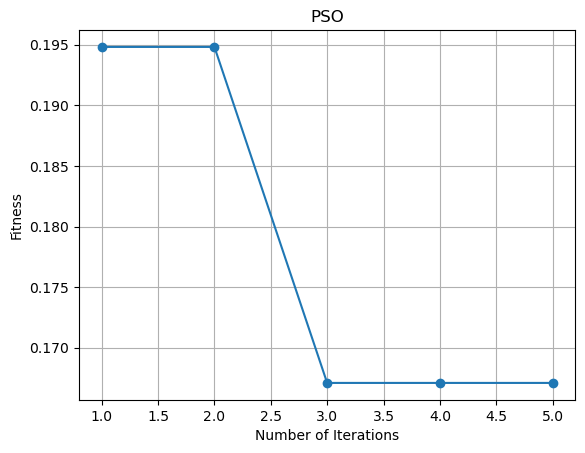

In [34]:
# plot convergence
curve   = fmdl['c']
curve   = curve.reshape(np.size(curve,1))
x       = np.arange(0, opts['T'], 1.0) + 1.0

fig, ax = plt.subplots()
ax.plot(x, curve, 'o-')
ax.set_xlabel('Number of Iterations')
ax.set_ylabel('Fitness')
ax.set_title('PSO')
ax.grid()
plt.show()

In [35]:
ML_Model = []
accuracy = []
precision = []
f1score = []
auc = []
spec = []
sens = []
mcc = []


#function to call for storing the results
def storeResults(model, a,b,c,d,e,f,g):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    f1score.append(round(c, 3))
    auc.append(round(d,3))
    spec.append(round(e,3))
    sens.append(round(f,3))
    mcc.append(round(g,3))

In [36]:
from sklearn.metrics import accuracy_score, precision_score, matthews_corrcoef, f1_score, roc_auc_score
from imblearn.metrics import specificity_score,sensitivity_score

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_fea, y_fea, test_size=0.20, random_state=42)
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((666, 5), (666, 1), (167, 5), (167, 1))

# Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='ovr', solver='liblinear', C=1.0)
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')
lr_auroc = roc_auc_score(y_train, lr.predict_proba(X_train)[:, 1])
lr_spec = specificity_score(y_valid, y_pred, average='weighted')
lr_sens = sensitivity_score(y_valid, y_pred, average='weighted')
lr_mcc = matthews_corrcoef(y_pred, y_valid)

In [44]:
storeResults('Anova-PSO LR',lr_acc,lr_prec,lr_f1,lr_auroc,lr_spec,lr_sens,lr_mcc)

# Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')
rf_auroc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
rf_spec = specificity_score(y_valid, y_pred, average='weighted')
rf_sens = sensitivity_score(y_valid, y_pred, average='weighted')
rf_mcc = matthews_corrcoef(y_pred, y_valid)

In [46]:
storeResults('Anova-PSO RF',rf_acc,rf_prec,rf_f1,rf_auroc,rf_spec,rf_sens,rf_mcc)

# ExtraTree

In [47]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier()
et.fit(X_train, y_train)

y_pred    = et.predict(X_valid)

et_acc = accuracy_score(y_pred, y_valid)
et_prec = precision_score(y_pred, y_valid,average='weighted')
et_f1 = f1_score(y_pred, y_valid,average='weighted')
et_auroc = roc_auc_score(y_train, et.predict_proba(X_train)[:, 1])
et_spec = specificity_score(y_valid, y_pred, average='weighted')
et_sens = sensitivity_score(y_valid, y_pred, average='weighted')
et_mcc = matthews_corrcoef(y_pred, y_valid)

In [48]:
storeResults('Anova-PSO ET',et_acc,et_prec,et_f1,et_auroc,et_spec,et_sens,et_mcc)

# Gradient Boosting

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0)

gbm.fit(X_train, y_train)
y_pred    = gbm.predict(X_valid)

gbm_acc = accuracy_score(y_pred, y_valid)
gbm_prec = precision_score(y_pred, y_valid,average='weighted')
gbm_f1 = f1_score(y_pred, y_valid,average='weighted')
gbm_auroc = roc_auc_score(y_train, gbm.predict_proba(X_train)[:, 1])
gbm_spec = specificity_score(y_valid, y_pred, average='weighted')
gbm_sens = sensitivity_score(y_valid, y_pred, average='weighted')
gbm_mcc = matthews_corrcoef(y_pred, y_valid)

In [50]:
storeResults('Anova-PSO GB',gbm_acc,gbm_prec,gbm_f1,gbm_auroc,gbm_spec,gbm_sens,gbm_mcc)

# Extension

In [54]:
from sklearn.ensemble import VotingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier

bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)
tree = ExtraTreesClassifier()

model = VotingClassifier(estimators=[('ET', tree),('BoostedDT', bdt)], voting='soft')

In [55]:
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)
ext_acc = accuracy_score(y_pred, y_valid)
ext_prec = precision_score(y_pred, y_valid,average='weighted')
ext_f1 = f1_score(y_pred, y_valid,average='weighted')
ext_auroc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
ext_spec = specificity_score(y_valid, y_pred, average='weighted')
ext_sens = sensitivity_score(y_valid, y_pred, average='weighted')
ext_mcc = matthews_corrcoef(y_pred, y_valid)

In [57]:
storeResults('Anova-PSO EXTENSION',ext_acc,ext_prec,ext_f1,ext_auroc,ext_spec,ext_sens,ext_mcc)

# Comparison

In [59]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'F1_score' : f1score,
                       'AUC' : auc,
                       'Specificity' : spec,
                       'Senstivity' : sens,
                        'MMC' : mcc
                      }) 

In [60]:
result

,ML Model,Accuracy,Precision,F1_score,AUC,Specificity,Senstivity,MMC
0,Anova-PSO LR,0.838,0.840,0.838,0.883,0.839,0.838,0.678
1,Anova-PSO RF,0.832,0.832,0.832,0.973,0.832,0.832,0.665
2,Anova-PSO ET,0.814,0.814,0.814,0.978,0.814,0.814,0.629
3,Anova-PSO GB,0.832,0.846,0.833,0.921,0.835,0.832,0.675
4,Anova-PSO EXTENSION,0.940,0.941,0.940,0.873,0.939,0.940,0.881


# Modelling

In [61]:
import joblib
filename = 'models/hhdd/model_anova.sav'
joblib.dump(model, filename)

['models/hhdd/model_anova.sav']

# Graph

In [64]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

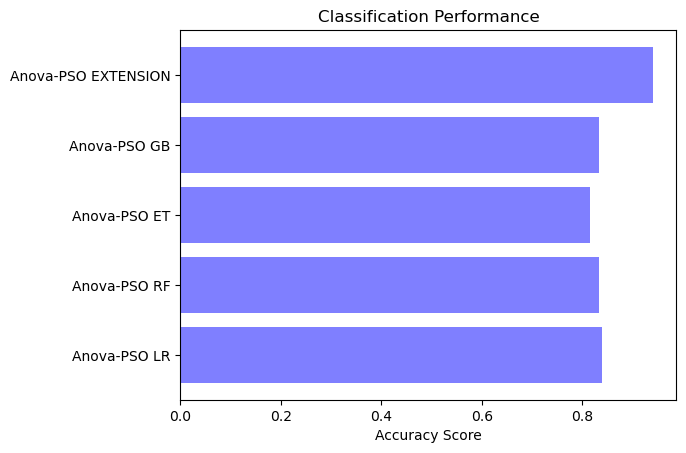

In [65]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

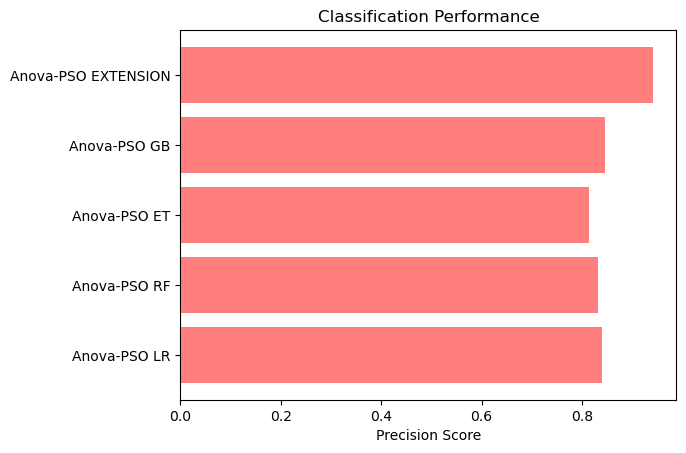

In [66]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

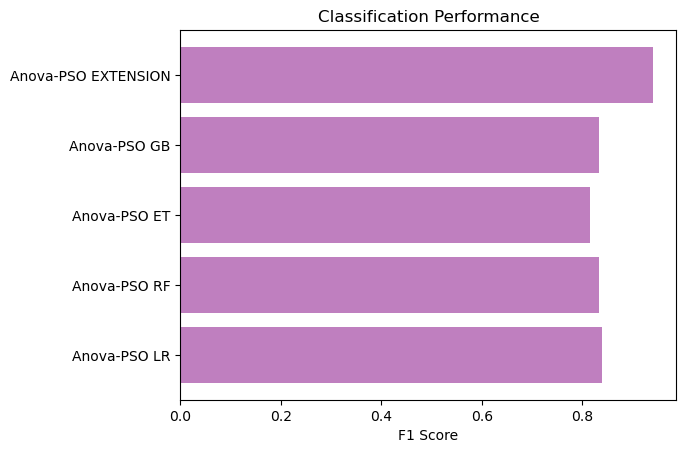

In [67]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='purple')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# AUC Score

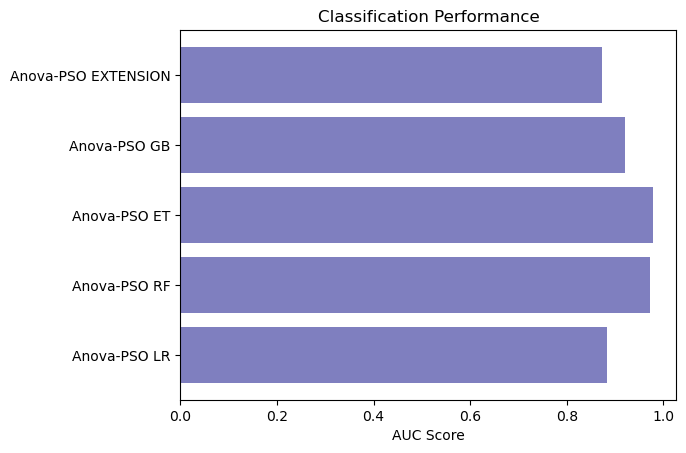

In [68]:
plt2.barh(y_pos, auc, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('AUC Score')
plt2.title('Classification Performance')
plt2.show()

# Specificity

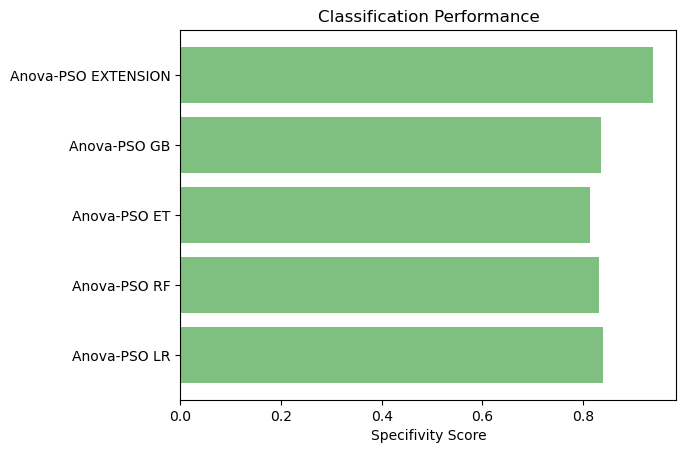

In [69]:
plt2.barh(y_pos, spec, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Specifivity Score')
plt2.title('Classification Performance')
plt2.show()

# Sensitivity

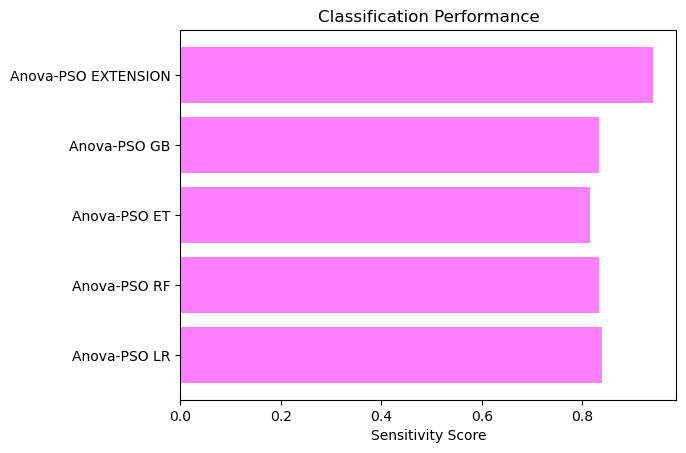

In [70]:
plt2.barh(y_pos, sens, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Sensitivity Score')
plt2.title('Classification Performance')
plt2.show()

# MMC

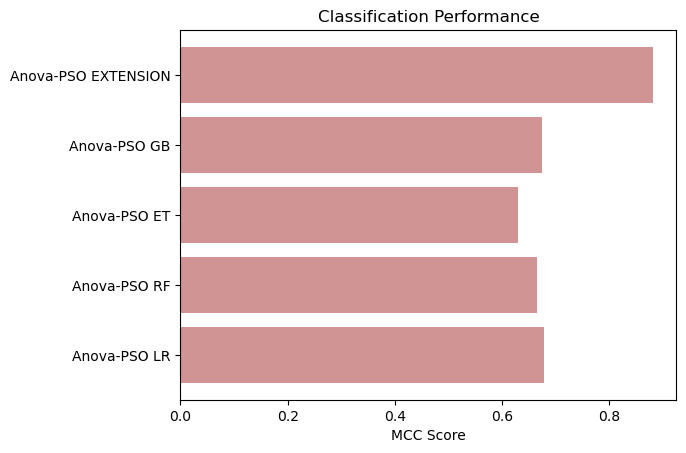

In [71]:
plt2.barh(y_pos, mcc, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('MCC Score')
plt2.title('Classification Performance')
plt2.show()

# MRMR FS

In [73]:
df = pd.read_csv('HHDD/heart_statlog_cleveland_hungary_final.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [78]:
X = df.drop(["target"],axis =1)
y = df["target"]

In [80]:
from mrmr import mrmr_classif
selected_features = mrmr_classif(X=X, y=y, K=10)

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.35it/s]


In [81]:
selected_features

['ST slope',
 'chest pain type',
 'sex',
 'exercise angina',
 'max heart rate',
 'oldpeak',
 'fasting blood sugar',
 'age',
 'cholesterol',
 'resting bp s']

In [82]:
df = df[['ST slope',
         'chest pain type',
         'sex',
         'exercise angina',
         'max heart rate',
         'oldpeak',
         'fasting blood sugar',
         'age',
         'cholesterol',
         'resting bp s','target']]

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ST slope             1190 non-null   int64  
 1   chest pain type      1190 non-null   int64  
 2   sex                  1190 non-null   int64  
 3   exercise angina      1190 non-null   int64  
 4   max heart rate       1190 non-null   int64  
 5   oldpeak              1190 non-null   float64
 6   fasting blood sugar  1190 non-null   int64  
 7   age                  1190 non-null   int64  
 8   cholesterol          1190 non-null   int64  
 9   resting bp s         1190 non-null   int64  
 10  target               1190 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 102.4 KB


# PSO

In [84]:
X = df.drop(["target"],axis =1)
y = df["target"]

In [85]:
X = X.values
y = y.values

In [86]:
feat  = np.asarray(X)
label = np.asarray(y)

In [87]:
# split data into train & validation (70 -- 30)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(feat, label, test_size=0.3, stratify=label)
fold = {'xt':xtrain, 'yt':ytrain, 'xv':xtest, 'yv':ytest}

In [88]:
# parameter
k    = 5     # k-value
N    = 5    # number of particles
T    = 5   # maximum number of iterations
opts = {'k':k, 'fold':fold, 'N':N, 'T':T}

# perform feature selection
fmdl = jfs(feat, label, opts)
sf   = fmdl['sf']

Iteration: 1
Best (PSO): 0.2331680672268907
Iteration: 2
Best (PSO): 0.22662184873949576
Iteration: 3
Best (PSO): 0.22662184873949576
Iteration: 4
Best (PSO): 0.22662184873949576
Iteration: 5
Best (PSO): 0.22662184873949576


In [89]:
df.columns

Index(['ST slope', 'chest pain type', 'sex', 'exercise angina',
       'max heart rate', 'oldpeak', 'fasting blood sugar', 'age',
       'cholesterol', 'resting bp s', 'target'],
      dtype='object')

In [90]:
sf

array([0, 6])

In [91]:
# model with selected features
num_train = np.size(xtrain, 0)

In [92]:
x = xtrain[:, sf]
y = ytrain.reshape(num_train)  # Solve bug

In [93]:
# number of selected features
num_feat = fmdl['nf']
print("Feature Size:", num_feat)

Feature Size: 2


In [94]:
X_fea = pd.DataFrame(x)
y_fea = pd.DataFrame(y)

In [95]:
result = pd.concat([X_fea, y_fea], axis=1, join='inner')
result.to_csv('HHDD/mrmr_processed.csv')

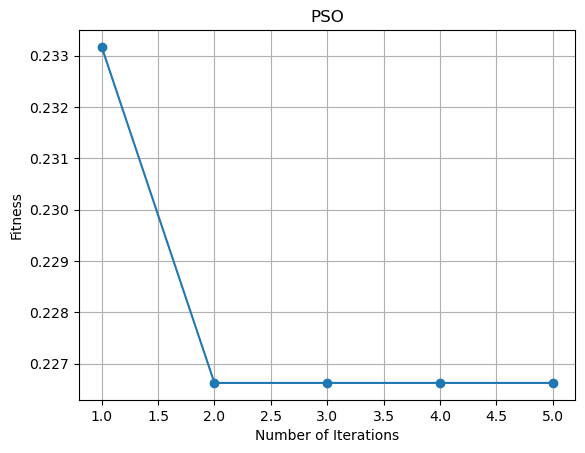

In [96]:
# plot convergence
curve   = fmdl['c']
curve   = curve.reshape(np.size(curve,1))
x       = np.arange(0, opts['T'], 1.0) + 1.0

fig, ax = plt.subplots()
ax.plot(x, curve, 'o-')
ax.set_xlabel('Number of Iterations')
ax.set_ylabel('Fitness')
ax.set_title('PSO')
ax.grid()
plt.show()

In [107]:
ML_Model = []
accuracy = []
precision = []
f1score = []
auc = []
spec = []
sens = []
mcc = []


#function to call for storing the results
def storeResults(model, a,b,c,d,e,f,g):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    f1score.append(round(c, 3))
    auc.append(round(d,3))
    spec.append(round(e,3))
    sens.append(round(f,3))
    mcc.append(round(g,3))

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_fea, y_fea, test_size=0.20, random_state=42)
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((666, 2), (666, 1), (167, 2), (167, 1))

# Logisitic Regression

In [99]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='ovr', solver='liblinear', C=1.0)
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')
lr_auroc = roc_auc_score(y_train, lr.predict_proba(X_train)[:, 1])
lr_spec = specificity_score(y_valid, y_pred, average='weighted')
lr_sens = sensitivity_score(y_valid, y_pred, average='weighted')
lr_mcc = matthews_corrcoef(y_pred, y_valid)

In [108]:
storeResults('MrMr-PSO LR',lr_acc,lr_prec,lr_f1,lr_auroc,lr_spec,lr_sens,lr_mcc)

# Random Forest

In [101]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')
rf_auroc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
rf_spec = specificity_score(y_valid, y_pred, average='weighted')
rf_sens = sensitivity_score(y_valid, y_pred, average='weighted')
rf_mcc = matthews_corrcoef(y_pred, y_valid)

In [109]:
storeResults('MrMr-PSO RF',rf_acc,rf_prec,rf_f1,rf_auroc,rf_spec,rf_sens,rf_mcc)

# ExtraTree

In [103]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier()
et.fit(X_train, y_train)

y_pred    = et.predict(X_valid)

et_acc = accuracy_score(y_pred, y_valid)
et_prec = precision_score(y_pred, y_valid,average='weighted')
et_f1 = f1_score(y_pred, y_valid,average='weighted')
et_auroc = roc_auc_score(y_train, et.predict_proba(X_train)[:, 1])
et_spec = specificity_score(y_valid, y_pred, average='weighted')
et_sens = sensitivity_score(y_valid, y_pred, average='weighted')
et_mcc = matthews_corrcoef(y_pred, y_valid)

In [110]:
storeResults('MrMr-PSO ET',et_acc,et_prec,et_f1,et_auroc,et_spec,et_sens,et_mcc)

# Gradient Boosting

In [105]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0)

gbm.fit(X_train, y_train)
y_pred    = gbm.predict(X_valid)

gbm_acc = accuracy_score(y_pred, y_valid)
gbm_prec = precision_score(y_pred, y_valid,average='weighted')
gbm_f1 = f1_score(y_pred, y_valid,average='weighted')
gbm_auroc = roc_auc_score(y_train, gbm.predict_proba(X_train)[:, 1])
gbm_spec = specificity_score(y_valid, y_pred, average='weighted')
gbm_sens = sensitivity_score(y_valid, y_pred, average='weighted')
gbm_mcc = matthews_corrcoef(y_pred, y_valid)

In [111]:
storeResults('MrMr-PSO GB',gbm_acc,gbm_prec,gbm_f1,gbm_auroc,gbm_spec,gbm_sens,gbm_mcc)

# Extension

In [112]:
bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)
tree = ExtraTreesClassifier()

model = VotingClassifier(estimators=[('ET', tree),('BoostedDT', bdt)], voting='soft')

In [113]:
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)
ext_acc = accuracy_score(y_pred, y_valid)
ext_prec = precision_score(y_pred, y_valid,average='weighted')
ext_f1 = f1_score(y_pred, y_valid,average='weighted')
ext_auroc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
ext_spec = specificity_score(y_valid, y_pred, average='weighted')
ext_sens = sensitivity_score(y_valid, y_pred, average='weighted')
ext_mcc = matthews_corrcoef(y_pred, y_valid)

In [115]:
storeResults('MrMr-PSO EXTENSION',ext_acc,ext_prec,ext_f1,ext_auroc,ext_spec,ext_sens,ext_mcc)

# Comparison

In [116]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'F1_score' : f1score,
                       'AUC' : auc,
                       'Specificity' : spec,
                       'Senstivity' : sens,
                        'MMC' : mcc
                      }) 

In [117]:
result

,ML Model,Accuracy,Precision,F1_score,AUC,Specificity,Senstivity,MMC
0,MrMr-PSO LR,0.85,0.851,0.85,0.783,0.851,0.85,0.7
1,MrMr-PSO RF,0.85,0.851,0.85,0.805,0.851,0.85,0.7
2,MrMr-PSO ET,0.85,0.851,0.85,0.805,0.851,0.85,0.7
3,MrMr-PSO GB,0.85,0.851,0.85,0.801,0.851,0.85,0.7
4,MrMr-PSO EXTENSION,0.85,0.851,0.85,0.805,0.851,0.85,0.7


# Graph

In [118]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

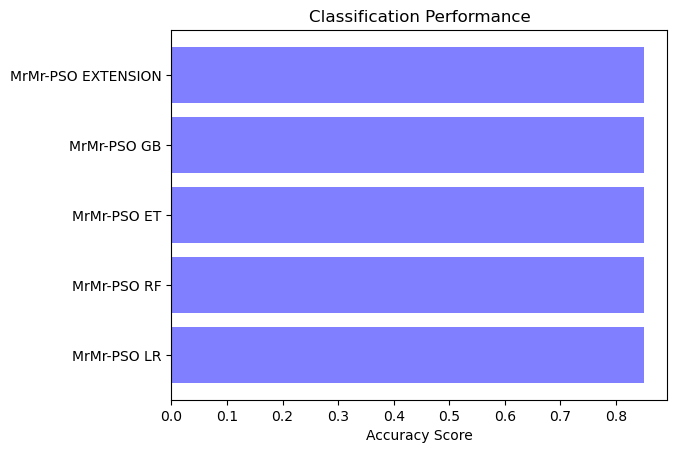

In [119]:
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

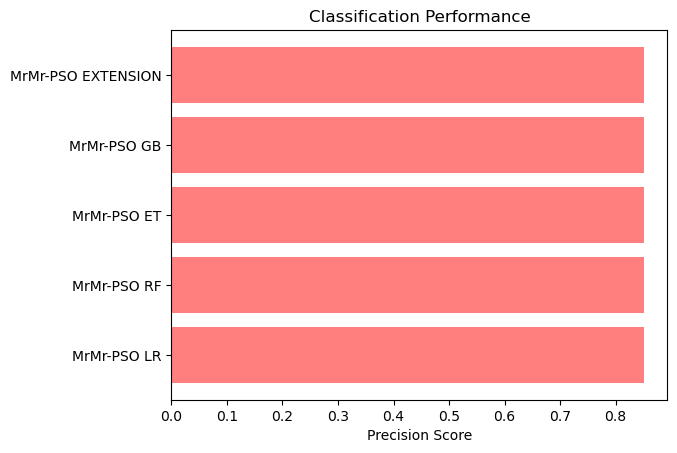

In [120]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

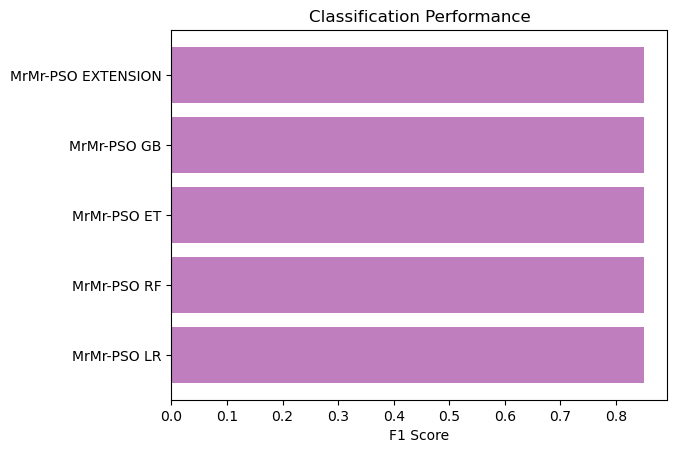

In [122]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='purple')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# AUC Score

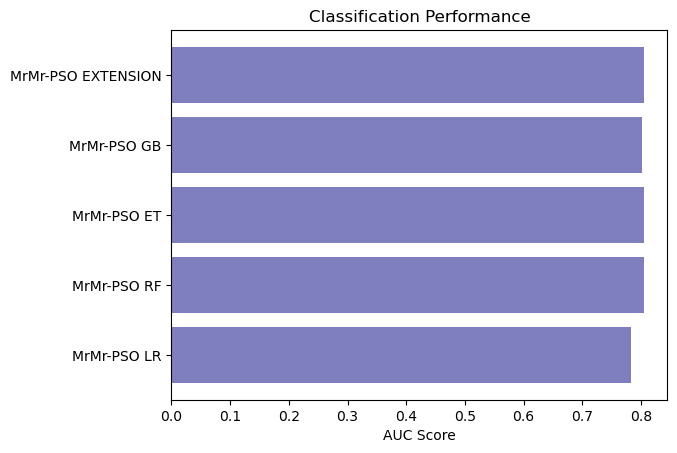

In [123]:
plt2.barh(y_pos, auc, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('AUC Score')
plt2.title('Classification Performance')
plt2.show()

# Specificity

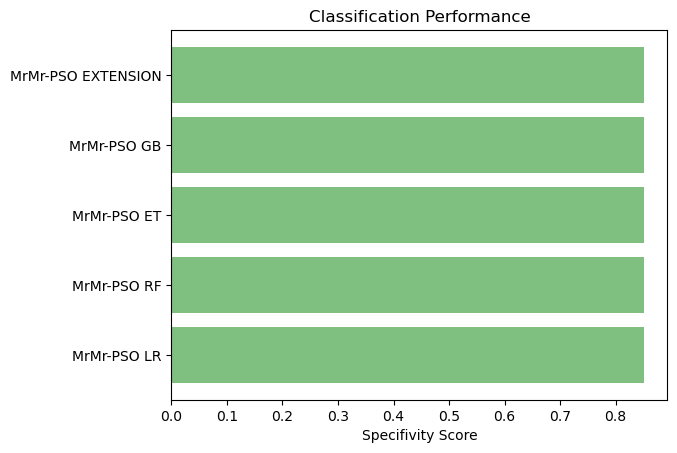

In [124]:
plt2.barh(y_pos, spec, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Specifivity Score')
plt2.title('Classification Performance')
plt2.show()

# Sensitivity

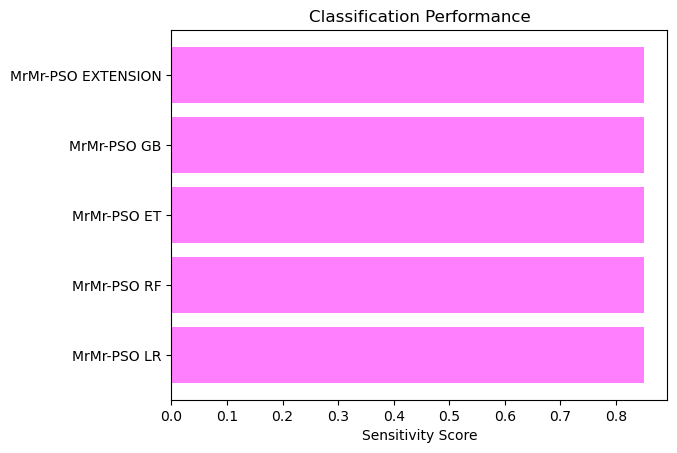

In [125]:
plt2.barh(y_pos, sens, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Sensitivity Score')
plt2.title('Classification Performance')
plt2.show()

# MMC

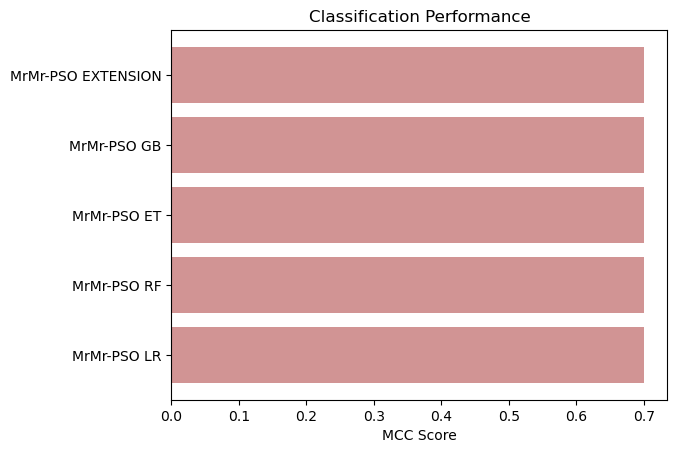

In [126]:
plt2.barh(y_pos, mcc, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('MCC Score')
plt2.title('Classification Performance')
plt2.show()

In [127]:
df = pd.read_csv('HHDD/heart_statlog_cleveland_hungary_final.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


# Lasso FS

In [128]:
from sklearn.linear_model import Lasso

In [129]:
X = df.drop(["target"],axis =1)
y = df["target"]

In [132]:
names=df.drop("target", axis=1).columns
print("Column Names: {}".format(names.values))

Column Names: ['age' 'sex' 'chest pain type' 'resting bp s' 'cholesterol'
 'fasting blood sugar' 'resting ecg' 'max heart rate' 'exercise angina'
 'oldpeak' 'ST slope']


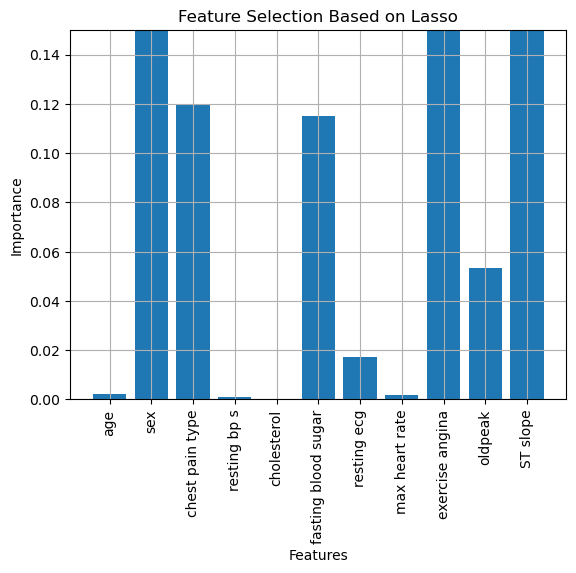

In [133]:
lasso1 = Lasso(alpha=0.00001)
lasso1.fit(X, y)

# Using np.abs() to make coefficients positive.  
lasso1_coef = np.abs(lasso1.coef_)

# plotting the Column Names and Importance of Columns. 
plt.bar(names, lasso1_coef)
plt.xticks(rotation=90)
plt.grid()
plt.title("Feature Selection Based on Lasso")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.ylim(0, 0.15)
plt.show()

In [134]:
# Subsetting the features which has more than 0.001 importance.
feature_subset=np.array(names)[lasso1_coef>0.001]
print("Selected Feature Columns: {}".format(feature_subset))

# Adding the target to the list of feaatures. 
feature_subset=np.append(feature_subset, "target")
print("Selected Columns: {}".format(feature_subset))

Selected Feature Columns: ['age' 'sex' 'chest pain type' 'fasting blood sugar' 'resting ecg'
 'max heart rate' 'exercise angina' 'oldpeak' 'ST slope']
Selected Columns: ['age' 'sex' 'chest pain type' 'fasting blood sugar' 'resting ecg'
 'max heart rate' 'exercise angina' 'oldpeak' 'ST slope' 'target']


In [136]:
df = df[['age', 'sex' ,'chest pain type', 'fasting blood sugar', 'resting ecg',
 'max heart rate', 'exercise angina', 'oldpeak' ,'ST slope','target']]

# PSO

In [137]:
X = df.drop(["target"],axis =1)
y = df["target"]

In [138]:
X = X.values
y = y.values

In [139]:
feat  = np.asarray(X)
label = np.asarray(y)

In [140]:
# split data into train & validation (70 -- 30)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(feat, label, test_size=0.3, stratify=label)
fold = {'xt':xtrain, 'yt':ytrain, 'xv':xtest, 'yv':ytest}

In [141]:
# parameter
k    = 5     # k-value
N    = 5    # number of particles
T    = 5   # maximum number of iterations
opts = {'k':k, 'fold':fold, 'N':N, 'T':T}

# perform feature selection
fmdl = jfs(feat, label, opts)
sf   = fmdl['sf']

Iteration: 1
Best (PSO): 0.21797385620915033
Iteration: 2
Best (PSO): 0.21797385620915033
Iteration: 3
Best (PSO): 0.2013352007469654
Iteration: 4
Best (PSO): 0.2013352007469654
Iteration: 5
Best (PSO): 0.18303454715219425


In [142]:
df.columns

Index(['age', 'sex', 'chest pain type', 'fasting blood sugar', 'resting ecg',
       'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')

In [143]:
sf

array([0, 1, 2, 7, 8])

In [144]:
# model with selected features
num_train = np.size(xtrain, 0)

In [145]:
x = xtrain[:, sf]
y = ytrain.reshape(num_train)  # Solve bug

In [146]:
# number of selected features
num_feat = fmdl['nf']
print("Feature Size:", num_feat)

Feature Size: 5


In [147]:
result = pd.concat([X_fea, y_fea], axis=1, join='inner')
result.to_csv('HHDD/lasso_processed.csv')

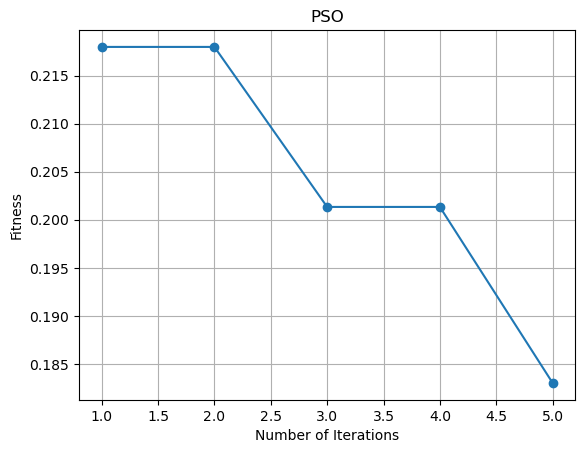

In [148]:
# plot convergence
curve   = fmdl['c']
curve   = curve.reshape(np.size(curve,1))
x       = np.arange(0, opts['T'], 1.0) + 1.0

fig, ax = plt.subplots()
ax.plot(x, curve, 'o-')
ax.set_xlabel('Number of Iterations')
ax.set_ylabel('Fitness')
ax.set_title('PSO')
ax.grid()
plt.show()

In [149]:
ML_Model = []
accuracy = []
precision = []
f1score = []
auc = []
spec = []
sens = []
mcc = []


#function to call for storing the results
def storeResults(model, a,b,c,d,e,f,g):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    f1score.append(round(c, 3))
    auc.append(round(d,3))
    spec.append(round(e,3))
    sens.append(round(f,3))
    mcc.append(round(g,3))

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_fea, y_fea, test_size=0.20, random_state=42)
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((666, 2), (666, 1), (167, 2), (167, 1))

# Logistic Regression

In [151]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='ovr', solver='liblinear', C=1.0)
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')
lr_auroc = roc_auc_score(y_train, lr.predict_proba(X_train)[:, 1])
lr_spec = specificity_score(y_valid, y_pred, average='weighted')
lr_sens = sensitivity_score(y_valid, y_pred, average='weighted')
lr_mcc = matthews_corrcoef(y_pred, y_valid)

In [152]:
storeResults('Lasso-PSO LR',lr_acc,lr_prec,lr_f1,lr_auroc,lr_spec,lr_sens,lr_mcc)

# Random Forest

In [153]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')
rf_auroc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
rf_spec = specificity_score(y_valid, y_pred, average='weighted')
rf_sens = sensitivity_score(y_valid, y_pred, average='weighted')
rf_mcc = matthews_corrcoef(y_pred, y_valid)

In [154]:
storeResults('Lasso-PSO RF',rf_acc,rf_prec,rf_f1,rf_auroc,rf_spec,rf_sens,rf_mcc)

# ExtraTree

In [155]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier()
et.fit(X_train, y_train)

y_pred    = et.predict(X_valid)

et_acc = accuracy_score(y_pred, y_valid)
et_prec = precision_score(y_pred, y_valid,average='weighted')
et_f1 = f1_score(y_pred, y_valid,average='weighted')
et_auroc = roc_auc_score(y_train, et.predict_proba(X_train)[:, 1])
et_spec = specificity_score(y_valid, y_pred, average='weighted')
et_sens = sensitivity_score(y_valid, y_pred, average='weighted')
et_mcc = matthews_corrcoef(y_pred, y_valid)

In [156]:
storeResults('Lasso-PSO ET',et_acc,et_prec,et_f1,et_auroc,et_spec,et_sens,et_mcc)

# Gradient Boosting

In [157]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0)

gbm.fit(X_train, y_train)
y_pred    = gbm.predict(X_valid)

gbm_acc = accuracy_score(y_pred, y_valid)
gbm_prec = precision_score(y_pred, y_valid,average='weighted')
gbm_f1 = f1_score(y_pred, y_valid,average='weighted')
gbm_auroc = roc_auc_score(y_train, gbm.predict_proba(X_train)[:, 1])
gbm_spec = specificity_score(y_valid, y_pred, average='weighted')
gbm_sens = sensitivity_score(y_valid, y_pred, average='weighted')
gbm_mcc = matthews_corrcoef(y_pred, y_valid)

In [158]:
storeResults('Lasso-PSO GB',gbm_acc,gbm_prec,gbm_f1,gbm_auroc,gbm_spec,gbm_sens,gbm_mcc)

# Extension

In [159]:
bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)
tree = ExtraTreesClassifier()

model = VotingClassifier(estimators=[('ET', tree),('BoostedDT', bdt)], voting='soft')

In [162]:
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)
ext_acc = accuracy_score(y_pred, y_valid)
ext_prec = precision_score(y_pred, y_valid,average='weighted')
ext_f1 = f1_score(y_pred, y_valid,average='weighted')
ext_auroc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
ext_spec = specificity_score(y_valid, y_pred, average='weighted')
ext_sens = sensitivity_score(y_valid, y_pred, average='weighted')
ext_mcc = matthews_corrcoef(y_pred, y_valid)

In [164]:
storeResults('Lasso-PSO EXTENSION',ext_acc,ext_prec,ext_f1,ext_auroc,ext_spec,ext_sens,ext_mcc)

# Comparison

In [165]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'F1_score' : f1score,
                       'AUC' : auc,
                       'Specificity' : spec,
                       'Senstivity' : sens,
                        'MMC' : mcc
                      }) 

In [166]:
result

,ML Model,Accuracy,Precision,F1_score,AUC,Specificity,Senstivity,MMC
0,Lasso-PSO LR,0.85,0.851,0.85,0.783,0.851,0.85,0.7
1,Lasso-PSO RF,0.85,0.851,0.85,0.805,0.851,0.85,0.7
2,Lasso-PSO ET,0.85,0.851,0.85,0.805,0.851,0.85,0.7
3,Lasso-PSO GB,0.85,0.851,0.85,0.801,0.851,0.85,0.7
4,Lasso-PSO EXTENSION,0.85,0.851,0.85,0.805,0.851,0.85,0.7


# Graph

In [167]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

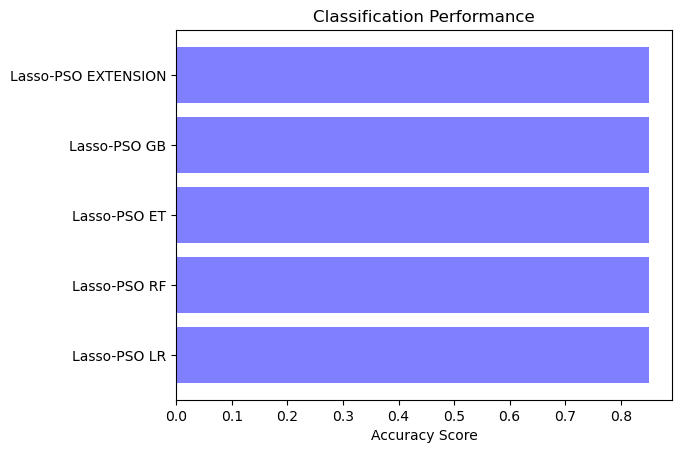

In [168]:
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

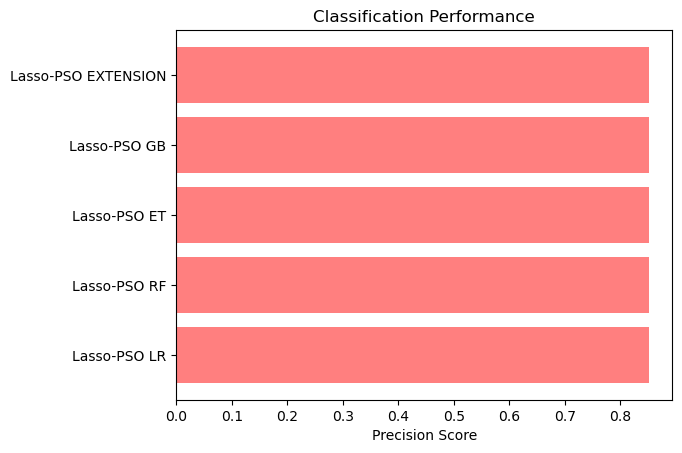

In [169]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

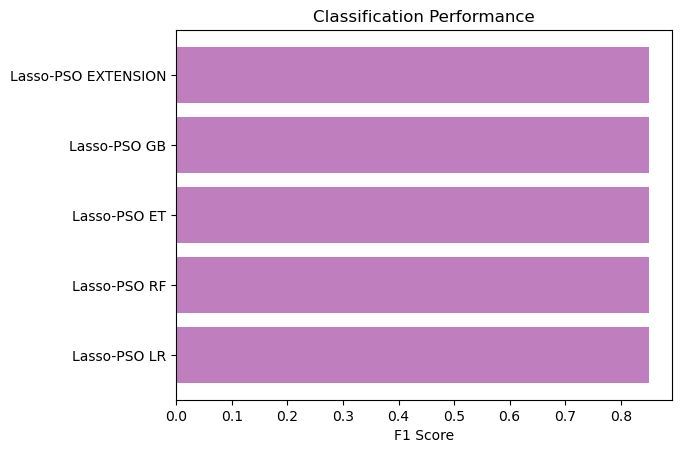

In [170]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='purple')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# AUC Score

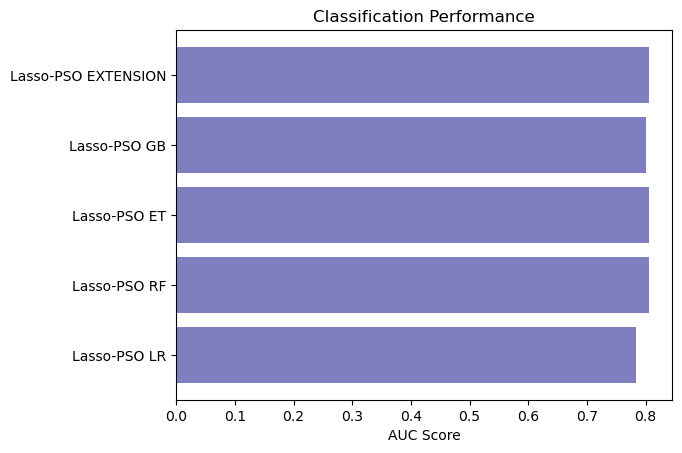

In [171]:
plt2.barh(y_pos, auc, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('AUC Score')
plt2.title('Classification Performance')
plt2.show()

# Specificity

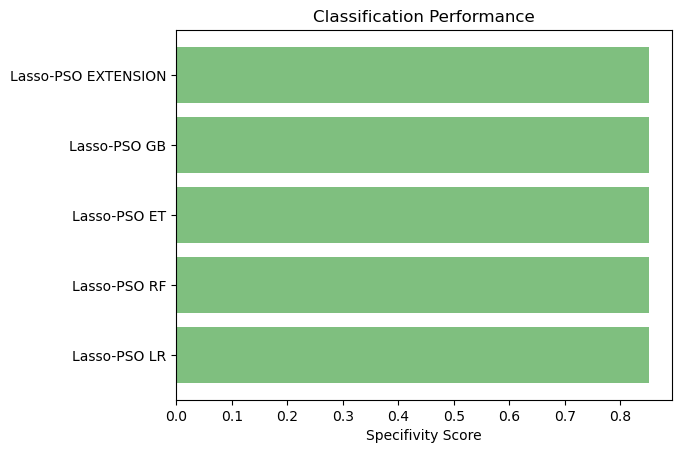

In [172]:
plt2.barh(y_pos, spec, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Specifivity Score')
plt2.title('Classification Performance')
plt2.show()

# Sensitivity

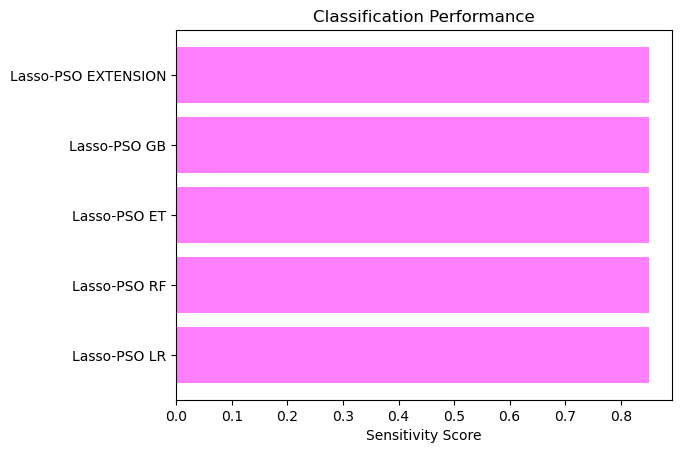

In [173]:
plt2.barh(y_pos, sens, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Sensitivity Score')
plt2.title('Classification Performance')
plt2.show()

# MMC

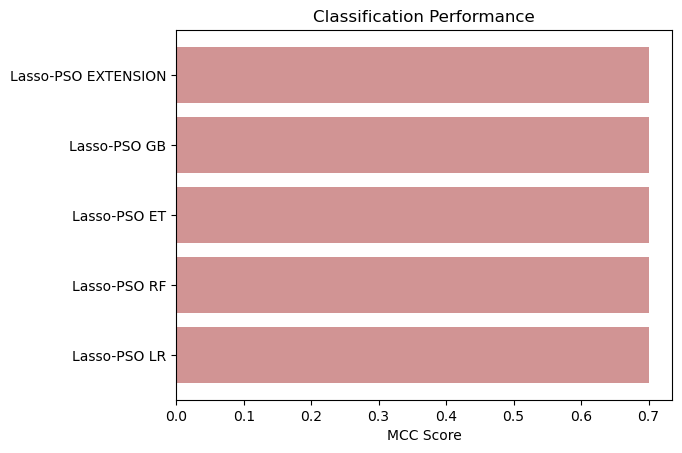

In [174]:
plt2.barh(y_pos, mcc, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('MCC Score')
plt2.title('Classification Performance')
plt2.show()

# FCBT

In [175]:
df = pd.read_csv('HHDD/heart_statlog_cleveland_hungary_final.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [176]:
X = df.drop(["target"],axis =1)
y = df["target"]

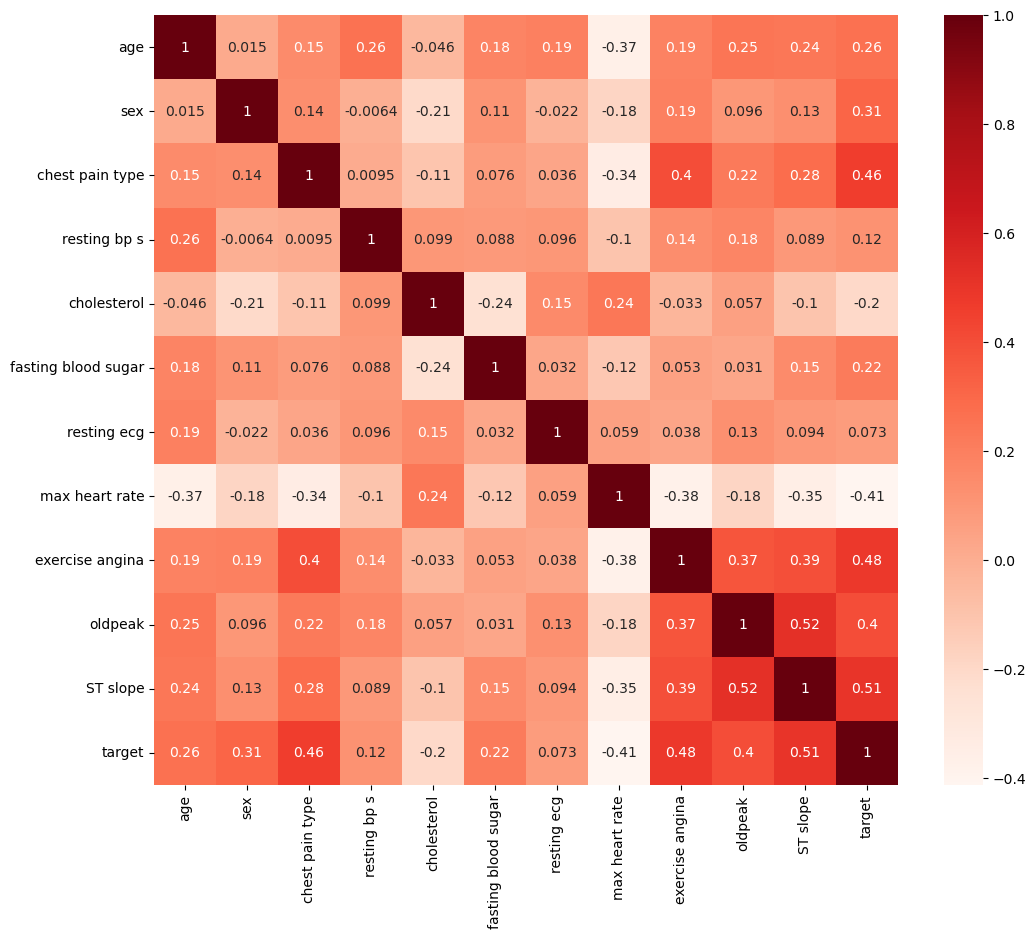

In [177]:
#Using Correlation
plt.figure(figsize=(12,10))
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [181]:
#Correlation with output variable
cor_target = abs(cor["target"])
#Selecting highly correlated features
relevant_features = cor_target[cor_target>0.1]
relevant_features

age                    0.262029
sex                    0.311267
chest pain type        0.460127
resting bp s           0.121415
cholesterol            0.198366
fasting blood sugar    0.216695
max heart rate         0.413278
exercise angina        0.481467
oldpeak                0.398385
ST slope               0.505608
target                 1.000000
Name: target, dtype: float64

In [182]:
df = df[['age','sex','chest pain type','resting bp s','cholesterol','fasting blood sugar',
        'max heart rate','exercise angina','oldpeak','ST slope','target']]

# PSO

In [183]:
X = df.drop(["target"],axis =1)
y = df["target"]

In [184]:
X = X.values
y = y.values

In [185]:
feat  = np.asarray(X)
label = np.asarray(y)

In [186]:
# split data into train & validation (70 -- 30)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(feat, label, test_size=0.2, stratify=label)
fold = {'xt':xtrain, 'yt':ytrain, 'xv':xtest, 'yv':ytest}

In [187]:
# parameter
k    = 10     # k-value
N    = 10    # number of particles
T    = 5   # maximum number of iterations
opts = {'k':k, 'fold':fold, 'N':N, 'T':T}

# perform feature selection
fmdl = jfs(feat, label, opts)
sf   = fmdl['sf']

Iteration: 1
Best (PSO): 0.29917647058823527
Iteration: 2
Best (PSO): 0.2379411764705883
Iteration: 3
Best (PSO): 0.20150420168067223
Iteration: 4
Best (PSO): 0.19634453781512604
Iteration: 5
Best (PSO): 0.1464285714285715


In [188]:
df.columns

Index(['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'max heart rate', 'exercise angina', 'oldpeak',
       'ST slope', 'target'],
      dtype='object')

In [189]:
sf

array([2, 5, 7, 8, 9])

In [190]:
# model with selected features
num_train = np.size(xtrain, 0)

In [191]:
x = xtrain[:, sf]
y = ytrain.reshape(num_train)  # Solve bug

In [192]:
# number of selected features
num_feat = fmdl['nf']
print("Feature Size:", num_feat)

Feature Size: 5


In [193]:
X_fea = pd.DataFrame(x)
y_fea = pd.DataFrame(y)

In [194]:
result = pd.concat([X_fea, y_fea], axis=1, join='inner')
result.to_csv('HHDD/fcbt_processed.csv')

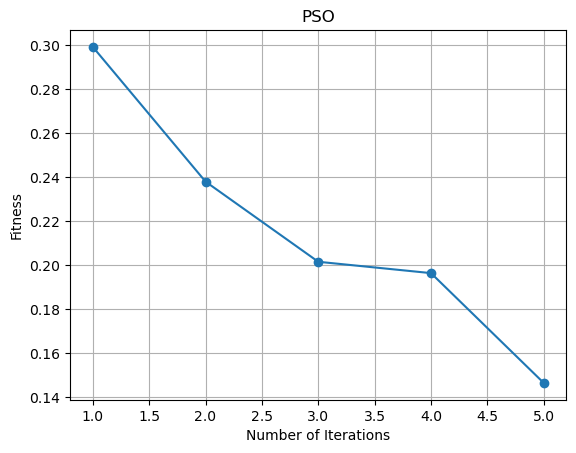

In [195]:
# plot convergence
curve   = fmdl['c']
curve   = curve.reshape(np.size(curve,1))
x       = np.arange(0, opts['T'], 1.0) + 1.0

fig, ax = plt.subplots()
ax.plot(x, curve, 'o-')
ax.set_xlabel('Number of Iterations')
ax.set_ylabel('Fitness')
ax.set_title('PSO')
ax.grid()
plt.show()

In [196]:
ML_Model = []
accuracy = []
precision = []
f1score = []
auc = []
spec = []
sens = []
mcc = []


#function to call for storing the results
def storeResults(model, a,b,c,d,e,f,g):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    f1score.append(round(c, 3))
    auc.append(round(d,3))
    spec.append(round(e,3))
    sens.append(round(f,3))
    mcc.append(round(g,3))

In [197]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_fea, y_fea, test_size=0.20, random_state=42)
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((761, 5), (761, 1), (191, 5), (191, 1))

# Logisitic Regression

In [198]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='ovr', solver='liblinear', C=1.0)
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')
lr_auroc = roc_auc_score(y_train, lr.predict_proba(X_train)[:, 1])
lr_spec = specificity_score(y_valid, y_pred, average='weighted')
lr_sens = sensitivity_score(y_valid, y_pred, average='weighted')
lr_mcc = matthews_corrcoef(y_pred, y_valid)

In [199]:
storeResults('FCBT-PSO LR',lr_acc,lr_prec,lr_f1,lr_auroc,lr_spec,lr_sens,lr_mcc)

# Random Forest

In [200]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')
rf_auroc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
rf_spec = specificity_score(y_valid, y_pred, average='weighted')
rf_sens = sensitivity_score(y_valid, y_pred, average='weighted')
rf_mcc = matthews_corrcoef(y_pred, y_valid)

In [201]:
storeResults('FCBT-PSO RF',rf_acc,rf_prec,rf_f1,rf_auroc,rf_spec,rf_sens,rf_mcc)

# Extra Tree

In [202]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier()
et.fit(X_train, y_train)

y_pred    = et.predict(X_valid)

et_acc = accuracy_score(y_pred, y_valid)
et_prec = precision_score(y_pred, y_valid,average='weighted')
et_f1 = f1_score(y_pred, y_valid,average='weighted')
et_auroc = roc_auc_score(y_train, et.predict_proba(X_train)[:, 1])
et_spec = specificity_score(y_valid, y_pred, average='weighted')
et_sens = sensitivity_score(y_valid, y_pred, average='weighted')
et_mcc = matthews_corrcoef(y_pred, y_valid)

In [203]:
storeResults('FCBT-PSO ET',et_acc,et_prec,et_f1,et_auroc,et_spec,et_sens,et_mcc)

# Gradient Boosting

In [204]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0)

gbm.fit(X_train, y_train)
y_pred    = gbm.predict(X_valid)

gbm_acc = accuracy_score(y_pred, y_valid)
gbm_prec = precision_score(y_pred, y_valid,average='weighted')
gbm_f1 = f1_score(y_pred, y_valid,average='weighted')
gbm_auroc = roc_auc_score(y_train, gbm.predict_proba(X_train)[:, 1])
gbm_spec = specificity_score(y_valid, y_pred, average='weighted')
gbm_sens = sensitivity_score(y_valid, y_pred, average='weighted')
gbm_mcc = matthews_corrcoef(y_pred, y_valid)

In [205]:
storeResults('FCBT-PSO GB',gbm_acc,gbm_prec,gbm_f1,gbm_auroc,gbm_spec,gbm_sens,gbm_mcc)

# Extension

In [206]:
bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)
tree = ExtraTreesClassifier()

model = VotingClassifier(estimators=[('ET', tree),('BoostedDT', bdt)], voting='soft')

In [207]:
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)
ext_acc = accuracy_score(y_pred, y_valid)
ext_prec = precision_score(y_pred, y_valid,average='weighted')
ext_f1 = f1_score(y_pred, y_valid,average='weighted')
ext_auroc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
ext_spec = specificity_score(y_valid, y_pred, average='weighted')
ext_sens = sensitivity_score(y_valid, y_pred, average='weighted')
ext_mcc = matthews_corrcoef(y_pred, y_valid)

In [208]:
storeResults('FCBT-PSO EXTENSION',ext_acc,ext_prec,ext_f1,ext_auroc,ext_spec,ext_sens,ext_mcc)

# Comparison

In [209]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'F1_score' : f1score,
                       'AUC' : auc,
                       'Specificity' : spec,
                       'Senstivity' : sens,
                        'MMC' : mcc
                      }) 

In [210]:
result

,ML Model,Accuracy,Precision,F1_score,AUC,Specificity,Senstivity,MMC
0,FCBT-PSO LR,0.843,0.857,0.844,0.877,0.844,0.843,0.696
1,FCBT-PSO RF,0.843,0.848,0.843,0.968,0.843,0.843,0.690
2,FCBT-PSO ET,0.859,0.859,0.859,0.974,0.859,0.859,0.718
3,FCBT-PSO GB,0.853,0.859,0.854,0.914,0.854,0.853,0.711
4,FCBT-PSO EXTENSION,0.948,0.950,0.948,0.884,0.948,0.948,0.897


# Modelling

In [211]:
import joblib
filename = 'models/hhdd/model_fcbt.sav'
joblib.dump(model, filename)

['models/hhdd/model_fcbt.sav']

# Graph

In [213]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

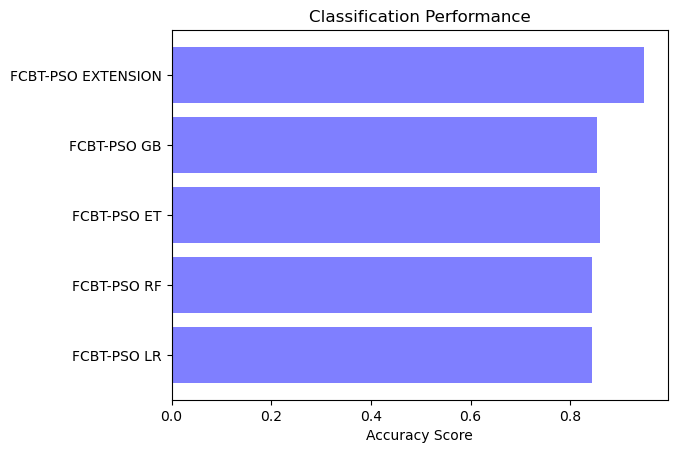

In [214]:
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

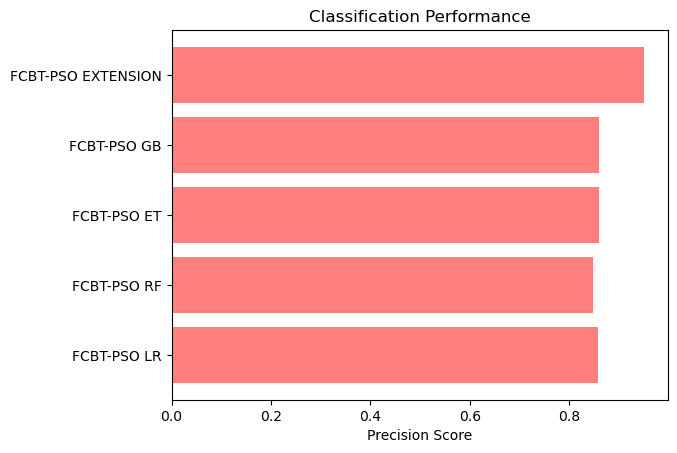

In [215]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

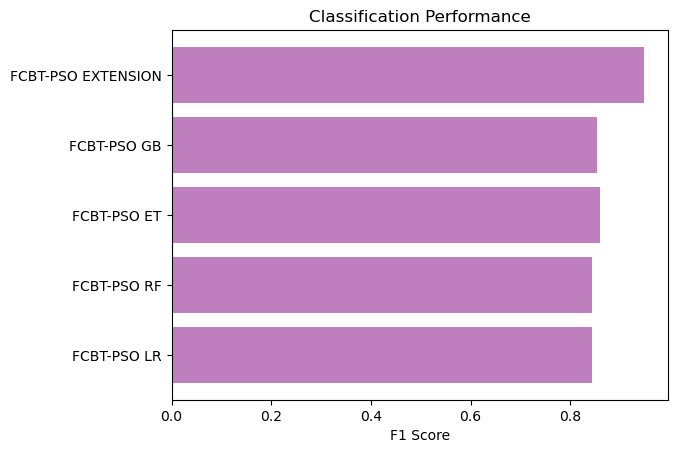

In [216]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='purple')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# AUC Score

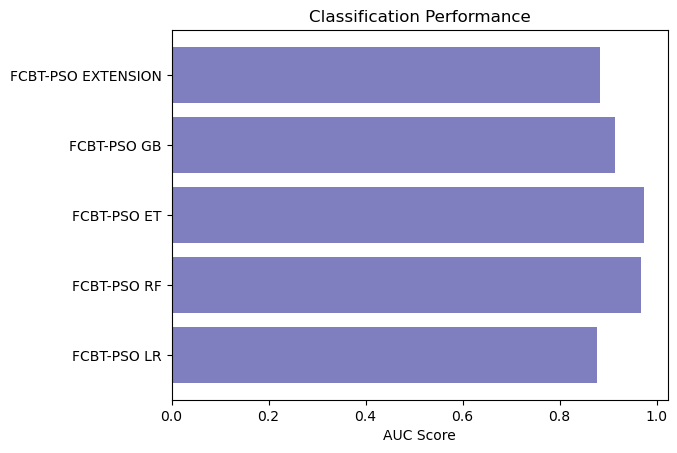

In [217]:
plt2.barh(y_pos, auc, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('AUC Score')
plt2.title('Classification Performance')
plt2.show()

# Specificity

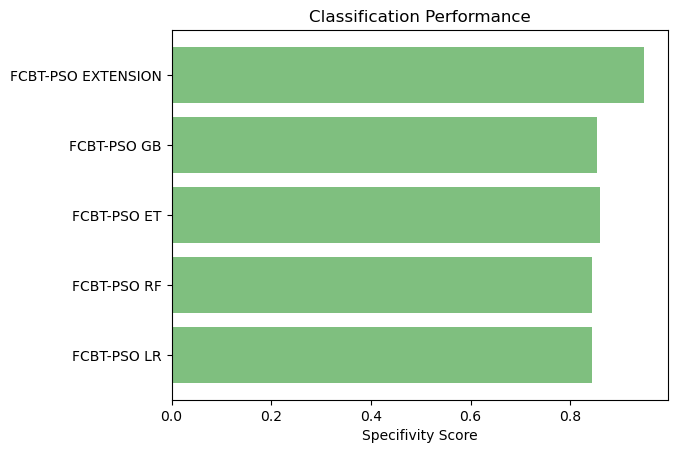

In [218]:
plt2.barh(y_pos, spec, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Specifivity Score')
plt2.title('Classification Performance')
plt2.show()

# Sensitivity

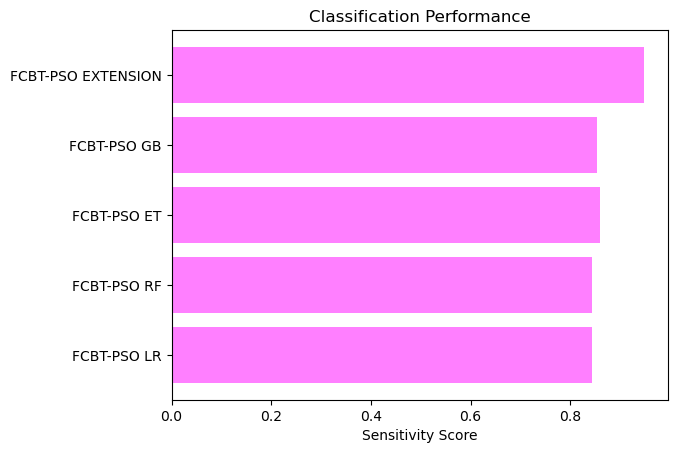

In [219]:
plt2.barh(y_pos, sens, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Sensitivity Score')
plt2.title('Classification Performance')
plt2.show()

# MMC

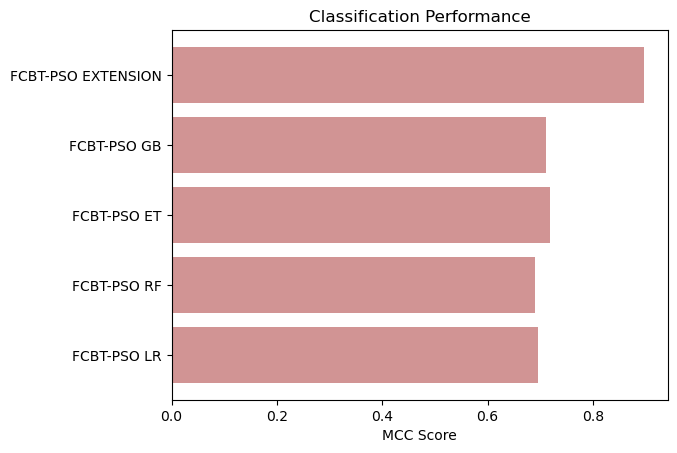

In [220]:
plt2.barh(y_pos, mcc, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('MCC Score')
plt2.title('Classification Performance')
plt2.show()

# ReliefF

In [3]:
df = pd.read_csv('HHDD/heart_statlog_cleveland_hungary_final.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [4]:
X = df.drop(["target"],axis =1)
y = df["target"]

In [5]:
from ReliefF import ReliefF

In [6]:
fs = ReliefF(n_neighbors=20, n_features_to_keep=7)

In [7]:
X = X.values
y = y.values

In [8]:
X_new = fs.fit_transform(X, y)

In [9]:
print("(No. of tuples, No. of Columns before ReliefF) : "+str(df.shape)+
      "\n(No. of tuples, No. of Columns after ReliefF) : "+str(X_new.shape))

(No. of tuples, No. of Columns before ReliefF) : (1190, 12)
(No. of tuples, No. of Columns after ReliefF) : (1190, 7)


In [10]:
X_new

array([[  1.,   0.,   1., ...,   0.,   0., 289.],
       [  2.,   0.,   0., ...,   0.,   0., 180.],
       [  1.,   0.,   1., ...,   0.,   1., 283.],
       ...,
       [  2.,   1.,   1., ...,   0.,   0., 131.],
       [  2.,   0.,   0., ...,   0.,   2., 236.],
       [  1.,   0.,   1., ...,   0.,   0., 175.]])

In [13]:
feat  = np.asarray(X_new)
label = np.asarray(y)

In [14]:
# split data into train & validation (70 -- 30)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(feat, label, test_size=0.3, stratify=label)
fold = {'xt':xtrain, 'yt':ytrain, 'xv':xtest, 'yv':ytest}

In [15]:
from FS.pso import jfs   # change this to switch algorithm 

In [16]:
# parameter
k    = 5     # k-value
N    = 5    # number of particles
T    = 5   # maximum number of iterations
opts = {'k':k, 'fold':fold, 'N':N, 'T':T}

# perform feature selection
fmdl = jfs(feat, label, opts)
sf   = fmdl['sf']

Iteration: 1
Best (PSO): 0.2302521008403361
Iteration: 2
Best (PSO): 0.19016806722689078
Iteration: 3
Best (PSO): 0.19016806722689078
Iteration: 4
Best (PSO): 0.1831932773109244
Iteration: 5
Best (PSO): 0.1831932773109244


In [17]:
sf

array([0, 1, 2, 4])

In [18]:
# model with selected features
num_train = np.size(xtrain, 0)

In [19]:
x = xtrain[:, sf]
y = ytrain.reshape(num_train)  # Solve bug

In [20]:
# number of selected features
num_feat = fmdl['nf']
print("Feature Size:", num_feat)

Feature Size: 4


In [21]:
X_fea = pd.DataFrame(x)
y_fea = pd.DataFrame(y)

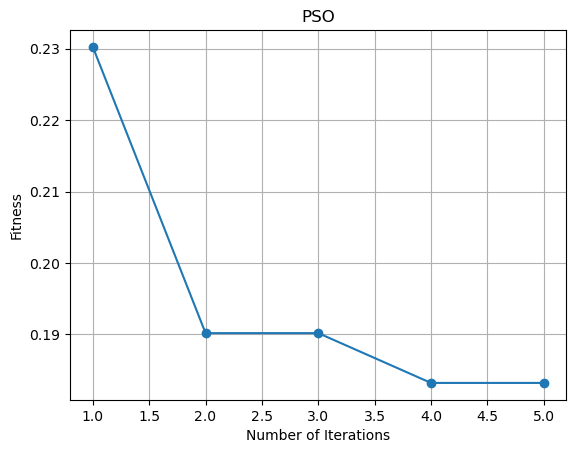

In [22]:
# plot convergence
curve   = fmdl['c']
curve   = curve.reshape(np.size(curve,1))
x       = np.arange(0, opts['T'], 1.0) + 1.0

fig, ax = plt.subplots()
ax.plot(x, curve, 'o-')
ax.set_xlabel('Number of Iterations')
ax.set_ylabel('Fitness')
ax.set_title('PSO')
ax.grid()
plt.show()

In [23]:
ML_Model = []
accuracy = []
precision = []
f1score = []
auc = []
spec = []
sens = []
mcc = []


#function to call for storing the results
def storeResults(model, a,b,c,d,e,f,g):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    f1score.append(round(c, 3))
    auc.append(round(d,3))
    spec.append(round(e,3))
    sens.append(round(f,3))
    mcc.append(round(g,3))

In [24]:
from sklearn.metrics import accuracy_score, precision_score, matthews_corrcoef, f1_score, roc_auc_score
from imblearn.metrics import specificity_score,sensitivity_score

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_fea, y_fea, test_size=0.20, random_state=42)
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((666, 4), (666, 1), (167, 4), (167, 1))

# Logistic Regession

In [26]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='ovr', solver='liblinear', C=1.0)
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')
lr_auroc = roc_auc_score(y_train, lr.predict_proba(X_train)[:, 1])
lr_spec = specificity_score(y_valid, y_pred, average='weighted')
lr_sens = sensitivity_score(y_valid, y_pred, average='weighted')
lr_mcc = matthews_corrcoef(y_pred, y_valid)

In [27]:
storeResults('Relief-PSO LR',lr_acc,lr_prec,lr_f1,lr_auroc,lr_spec,lr_sens,lr_mcc)

# Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')
rf_auroc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
rf_spec = specificity_score(y_valid, y_pred, average='weighted')
rf_sens = sensitivity_score(y_valid, y_pred, average='weighted')
rf_mcc = matthews_corrcoef(y_pred, y_valid)

In [29]:
storeResults('Relief-PSO RF',rf_acc,rf_prec,rf_f1,rf_auroc,rf_spec,rf_sens,rf_mcc)

# ExtraTree

In [30]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier()
et.fit(X_train, y_train)

y_pred    = et.predict(X_valid)

et_acc = accuracy_score(y_pred, y_valid)
et_prec = precision_score(y_pred, y_valid,average='weighted')
et_f1 = f1_score(y_pred, y_valid,average='weighted')
et_auroc = roc_auc_score(y_train, et.predict_proba(X_train)[:, 1])
et_spec = specificity_score(y_valid, y_pred, average='weighted')
et_sens = sensitivity_score(y_valid, y_pred, average='weighted')
et_mcc = matthews_corrcoef(y_pred, y_valid)

In [31]:
storeResults('Relief-PSO ET',et_acc,et_prec,et_f1,et_auroc,et_spec,et_sens,et_mcc)

# Graadient Boosting

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0)

gbm.fit(X_train, y_train)
y_pred    = gbm.predict(X_valid)

gbm_acc = accuracy_score(y_pred, y_valid)
gbm_prec = precision_score(y_pred, y_valid,average='weighted')
gbm_f1 = f1_score(y_pred, y_valid,average='weighted')
gbm_auroc = roc_auc_score(y_train, gbm.predict_proba(X_train)[:, 1])
gbm_spec = specificity_score(y_valid, y_pred, average='weighted')
gbm_sens = sensitivity_score(y_valid, y_pred, average='weighted')
gbm_mcc = matthews_corrcoef(y_pred, y_valid)

In [33]:
storeResults('Relief-PSO GB',gbm_acc,gbm_prec,gbm_f1,gbm_auroc,gbm_spec,gbm_sens,gbm_mcc)

# Extension

In [34]:
from sklearn.ensemble import VotingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier

bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)
tree = ExtraTreesClassifier()

model = VotingClassifier(estimators=[('ET', tree),('BoostedDT', bdt)], voting='soft')

In [35]:
model.fit(X_valid, y_valid)

y_pred = model.predict(X_valid)
ext_acc = accuracy_score(y_pred, y_valid)
ext_prec = precision_score(y_pred, y_valid,average='weighted')
ext_f1 = f1_score(y_pred, y_valid,average='weighted')
ext_auroc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
ext_spec = specificity_score(y_valid, y_pred, average='weighted')
ext_sens = sensitivity_score(y_valid, y_pred, average='weighted')
ext_mcc = matthews_corrcoef(y_pred, y_valid)

In [36]:
storeResults('Relief-PSO EXTENSION',ext_acc,ext_prec,ext_f1,ext_auroc,ext_spec,ext_sens,ext_mcc)

# Comparison

In [37]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'F1_score' : f1score,
                       'AUC' : auc,
                       'Specificity' : spec,
                       'Senstivity' : sens,
                        'MMC' : mcc
                      }) 

In [38]:
result

,ML Model,Accuracy,Precision,F1_score,AUC,Specificity,Senstivity,MMC
0,Relief-PSO LR,0.832,0.833,0.832,0.862,0.833,0.832,0.665
1,Relief-PSO RF,0.844,0.845,0.844,0.891,0.845,0.844,0.690
2,Relief-PSO ET,0.844,0.845,0.844,0.892,0.845,0.844,0.690
3,Relief-PSO GB,0.850,0.850,0.850,0.880,0.850,0.850,0.700
4,Relief-PSO EXTENSION,0.856,0.856,0.856,0.866,0.857,0.856,0.713


# Graph

In [39]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

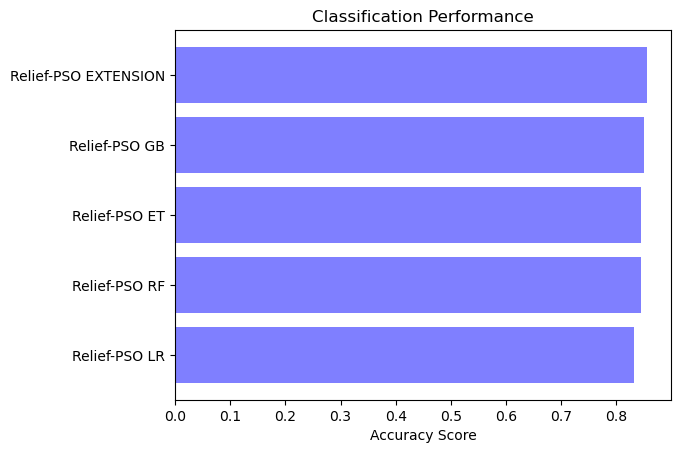

In [40]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

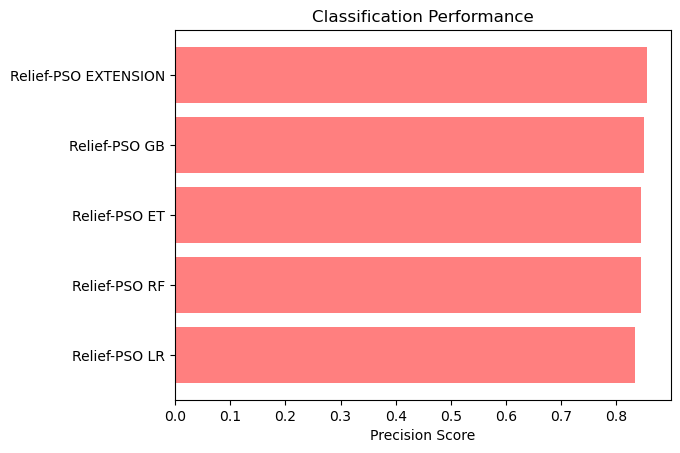

In [41]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# F1 SCore

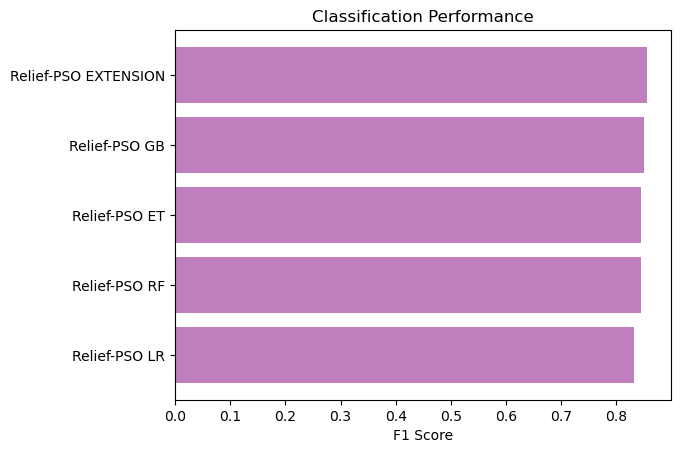

In [42]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='purple')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# AUC Score

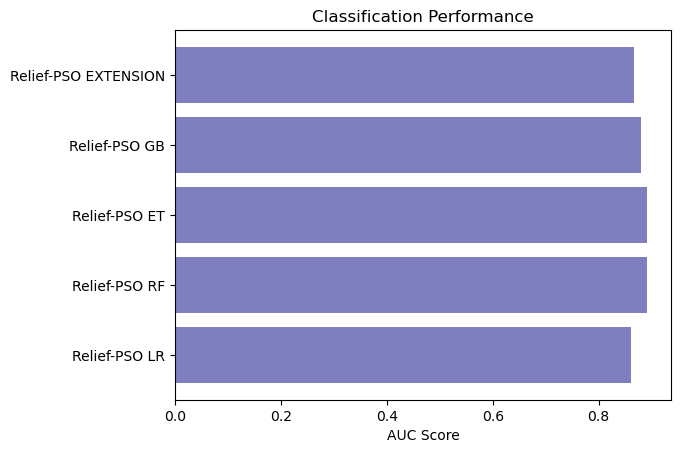

In [43]:
plt2.barh(y_pos, auc, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('AUC Score')
plt2.title('Classification Performance')
plt2.show()

# Specificity

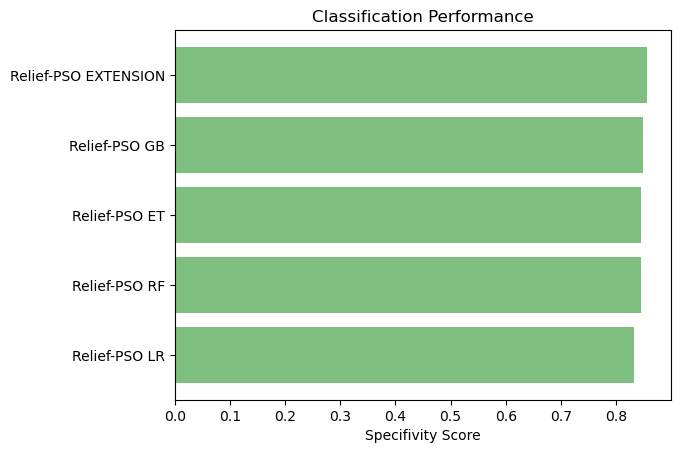

In [44]:
plt2.barh(y_pos, spec, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Specifivity Score')
plt2.title('Classification Performance')
plt2.show()

# Sensitivity

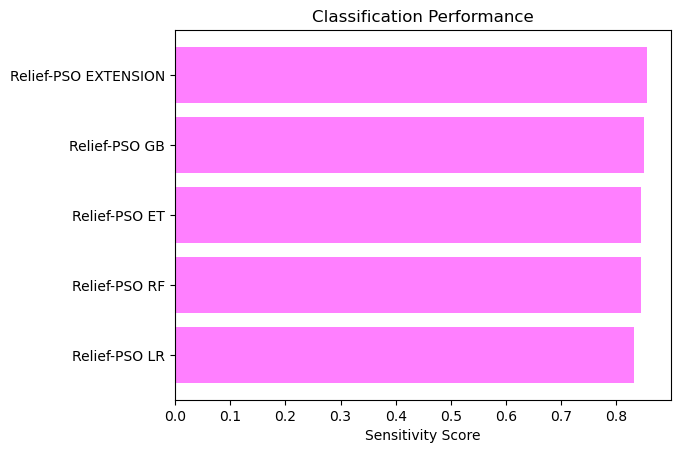

In [45]:
plt2.barh(y_pos, sens, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Sensitivity Score')
plt2.title('Classification Performance')
plt2.show()

# MMC

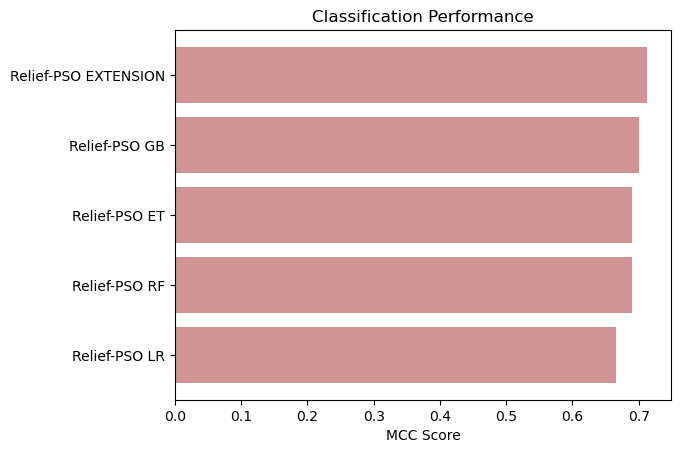

In [46]:
plt2.barh(y_pos, mcc, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('MCC Score')
plt2.title('Classification Performance')
plt2.show()